In [1]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pykalman import KalmanFilter
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import os

# Scripts 
from utils.backtest import *
from utils.cointegration import *
from utils.kalman import *
from utils.pairs import *
from utils.plots import *

# Import data <br>
- Create algorithm to compute cointegrated pairs (pairs-det.py)
- Do human check on the pairs that the algorithm chose by plotting pairs and computing simple EDA

In [2]:
# 收集数据来自 Bloomberg 然后将这些对整理到 x 和 y 字典中。 

"""
df1 = tech assets 
df2 = commodities assets 
df = tech + commodities merged together
"""

df1 = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/tech.csv")
df2 = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/commodites.csv")

df = pd.merge(df1, df2, how='left', on='Date')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date')
df = df.sort_index()

In [3]:
df.head()

,700 HK Equity,9988 HK Equity,1211 HK Equity,1810 HK Equity,300 HK Equity,981 HK Equity,9999 HK Equity,3690 HK Equity,9618 HK Equity,9888 HK Equity,...,3858 HK Equity,1258 HK Equity,3668 HK Equity,3330 HK Equity,1164 HK Equity,2689 HK Equity,2386 HK Equity,2610 HK Equity,3899 HK Equity,189 HK Equity
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,99.201,167.118,10.025,17.00,51.930,7.4,109.815,69.00,199.037,252.0,...,10.92,1.456,11.021,1.107,0.677,5.111,2.776,26.191,4.633,1.885
2015-01-05,99.817,178.133,10.025,16.80,56.004,7.4,116.405,72.65,206.082,252.0,...,30.34,1.456,10.960,1.090,0.668,5.140,2.829,24.862,4.780,1.925
2015-01-06,105.533,183.450,10.072,19.00,60.885,7.1,115.062,72.10,205.730,250.8,...,30.00,1.456,10.726,1.090,0.659,5.118,2.843,24.862,4.663,1.891
2015-01-07,109.403,193.705,9.219,19.00,60.648,7.2,112.018,69.00,200.798,226.6,...,33.82,1.456,10.655,1.082,0.677,4.894,2.838,23.681,4.648,1.911
2015-01-08,111.953,188.388,9.330,19.26,64.059,7.0,116.137,68.80,202.560,214.0,...,32.50,1.421,10.491,1.140,0.686,4.706,2.819,23.336,4.663,1.898


### Ticker - Company Name
| Ticker (Tech) | Company (Tech)                     | Ticker (Energy/Materials) | Company (Energy/Materials)        |
|---------------|------------------------------------|---------------------------|-----------------------------------|
| 700 HK Equity | TENCENT HOLDINGS LTD              | 857 HK Equity             | PETROCHINA CO LTD-H               |
| 9988 HK Equity| ALIBABA GROUP HOLDING LTD         | 883 HK Equity             | CNOOC LTD-H                       |
| 1211 HK Equity| BYD CO LTD-H                      | 1088 HK Equity            | CHINA SHENHUA ENERGY CO-H         |
| 1810 HK Equity| XIAOMI CORP-CLASS B               | 2899 HK Equity            | ZIJIN MINING GROUP CO LTD-H       |
| 300 HK Equity | MIDEA GROUP CO LTD-H              | 386 HK Equity             | CHINA PETROLEUM & CHEMICAL-H      |
| 981 HK Equity | SEMICONDUCTOR MANUFACTURING-H     | 3993 HK Equity            | CMOC GROUP LTD-H                  |
| 9999 HK Equity| NETEASE INC                       | 2259 HK Equity            | ZIJIN GOLD INTERNATIONAL CO       |
| 3690 HK Equity| MEITUAN-CLASS B                   | 1378 HK Equity            | CHINA HONGQIAO GROUP LTD          |
| 9618 HK Equity| JD.COM INC-CLASS A                | 2600 HK Equity            | ALUMINUM CORP OF CHINA LTD-H      |
| 9888 HK Equity| BAIDU INC-CLASS A                 | 1898 HK Equity            | CHINA COAL ENERGY CO-H            |
| 9961 HK Equity| TRIP.COM GROUP LTD                | 1772 HK Equity            | GANFENG LITHIUM GROUP CO L-H      |
| 6690 HK Equity| HAIER SMART HOME CO LTD-H         | 1787 HK Equity            | SHANDONG GOLD MINING CO LT-H      |
| 1024 HK Equity| KUAISHOU TECHNOLOGY               | 1171 HK Equity            | YANKUANG ENERGY GROUP CO-H        |
| 1347 HK Equity| HUA HONG SEMICONDUCTOR LTD-H      | 358 HK Equity             | JIANGXI COPPER CO LTD-H           |
| 2015 HK Equity| LI AUTO INC-CLASS A               | 1818 HK Equity            | ZHAOJIN MINING INDUSTRY CO-H      |
| 6618 HK Equity| JD HEALTH INTERNATIONAL INC       | 1208 HK Equity            | MMG LTD                           |
| 992 HK Equity | LENOVO GROUP LTD                  | 2099 HK Equity            | CHINA GOLD INTERNATIONAL RES      |
| 9866 HK Equity| NIO INC-CLASS A                   | 2883 HK Equity            | CHINA OILFIELD SERVICES-H         |
| 9868 HK Equity| XPENG INC - CLASS A SHARES        | 2788 HK Equity            | CHUANGXIN INDUSTRIES HOLDING      |
| 1698 HK Equity| TENCENT MUSIC ENT - CLASS A       | 3939 HK Equity            | WANGUO GOLD GROUP LTD             |
| 9660 HK Equity| HORIZON ROBOTICS INC              | 3858 HK Equity            | JIAXIN INTERNATIONAL RESOURC      |
| 20 HK Equity  | SENSE TIME GROUP INC-CLASS B      | 1258 HK Equity            | CHINA NONFERROUS MINING CORP      |
| 9626 HK Equity| BILIBILI INC-CLASS Z              | 3668 HK Equity            | YANCOAL AUSTRALIA LTD             |
| 241 HK Equity | ALIBABA HEALTH INFORMATION TECH   | 3330 HK Equity            | LINGBAO GOLD GROUP CO LTD-H       |
| 9863 HK Equity| ZHEJIANG LEAPMOTOR TECHNOLOGY-H   | 1164 HK Equity            | CGN MINING CO LTD                 |
| 2382 HK Equity| SUNNY OPTICAL TECH                | 2689 HK Equity            | NINE DRAGONS PAPER HOLDINGS       |
| 285 HK Equity | BYD ELECTRONIC INTL CO LTD        | 2386 HK Equity            | SINOPEC ENGINEERING GROUP-H       |
| 780 HK Equity | TONGCHENG TRAVEL HOLDINGS LTD     | 2610 HK Equity            | NANSHAN ALUMINIUM INTERNATIO      |
| 3888 HK Equity| KINGSOFT CORP LTD                 | 3899 HK Equity            | CIMC ENRIC HOLDINGS LTD           |
| 268 HK Equity | KINGDEE INTERNATIONAL SOFTWARE    | 189 HK Equity             | DONGYUE GROUP                     |

In [4]:
# Set the time index for our respective dataframes
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df1 = df1.set_index('Date')

df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)
df2 = df2.set_index('Date')

In [5]:
# Removing equities that don't have enough data

df1 = df1.loc[:'2023-01-31']
last_date = df1.index.max()
df1 = df1.loc[:, df1.loc[last_date].notna()]
df1.head()

,700 HK Equity,1211 HK Equity,981 HK Equity,1347 HK Equity,992 HK Equity,241 HK Equity,2382 HK Equity,285 HK Equity,3888 HK Equity,268 HK Equity
Date,,,,,,,,,,
2015-01-02,99.201,10.025,7.4,8.807,6.069,5.11,12.130,6.923,14.711,2.332
2015-01-05,99.817,10.025,7.4,8.690,5.974,4.97,12.240,7.100,15.243,2.342
2015-01-06,105.533,10.072,7.1,8.923,5.985,5.00,12.111,6.914,15.300,2.303
2015-01-07,109.403,9.219,7.2,8.833,6.187,4.97,11.560,7.286,15.603,2.372
2015-01-08,111.953,9.330,7.0,8.878,6.437,5.00,10.788,7.809,15.338,2.382


In [6]:
df2 = df2.loc[:'2023-01-31']
last_date = df2.index.max()
df2 = df2.loc[:, df2.loc[last_date].notna()]
df2.head()

,857 HK Equity,883 HK Equity,1088 HK Equity,2899 HK Equity,386 HK Equity,3993 HK Equity,1378 HK Equity,2600 HK Equity,1898 HK Equity,1171 HK Equity,...,2099 HK Equity,2883 HK Equity,3939 HK Equity,1258 HK Equity,3330 HK Equity,1164 HK Equity,2689 HK Equity,2386 HK Equity,3899 HK Equity,189 HK Equity
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,4.784,4.775,8.437,1.633,2.768,1.178,2.517,3.189,3.174,1.170,...,11.288,10.835,0.460,1.456,1.107,0.677,5.111,2.776,4.633,1.885
2015-01-05,4.811,4.784,8.546,1.693,2.803,1.238,2.624,3.586,3.251,1.226,...,11.456,10.977,0.466,1.456,1.090,0.668,5.140,2.829,4.780,1.925
2015-01-06,4.696,4.631,8.528,1.707,2.750,1.231,2.605,3.640,3.200,1.224,...,11.589,10.427,0.474,1.456,1.090,0.659,5.118,2.843,4.663,1.891
2015-01-07,4.718,4.622,8.564,1.744,2.750,1.254,2.571,3.739,3.219,1.224,...,11.840,10.490,0.480,1.456,1.082,0.677,4.894,2.838,4.648,1.911
2015-01-08,4.833,4.703,8.473,1.811,2.763,1.248,2.576,3.694,3.200,1.234,...,11.522,10.584,0.482,1.421,1.140,0.686,4.706,2.819,4.663,1.898


In [7]:
# Transforming raw prices into log prices
df1 = np.log(df1)
df2 = np.log(df2)

Therefore, with tech, we can have 45 potential pairs and with commodities we can have 253 (*210*) potential pairs, given:
$$
\text{Pairs} = \frac{(n\times(n-1))}{2}
$$

### Calculate Returns and run basic EDA (identify outliers and form correlation matrix)

$$
r_t = ln(\frac{P_{t}}{P_{t-1}})
$$

In [8]:
# For tech
tech_returns = (df1 - df1.shift(1)).dropna()
print(tech_returns)

# For commodities
comm_returns = (df2 - df2.shift(1)).dropna()
print(comm_returns)

            700 HK Equity  1211 HK Equity  981 HK Equity  1347 HK Equity  \
Date                                                                       
2015-01-05       0.006190        0.000000       0.000000       -0.013374   
2015-01-06       0.055685        0.004677      -0.041385        0.026459   
2015-01-07       0.036015       -0.088493       0.013986       -0.010138   
2015-01-08       0.023041        0.011968      -0.028171        0.005082   
2015-01-09      -0.000786        0.011721       0.014185       -0.022440   
...                   ...             ...            ...             ...   
2023-01-20       0.023238       -0.000874       0.016998        0.004836   
2023-01-26       0.037571        0.058331       0.033152        0.065236   
2023-01-27       0.019956        0.025502      -0.004357       -0.006024   
2023-01-30      -0.069336       -0.027167      -0.051523       -0.052822   
2023-01-31      -0.012998        0.022279      -0.009238       -0.037365   

           

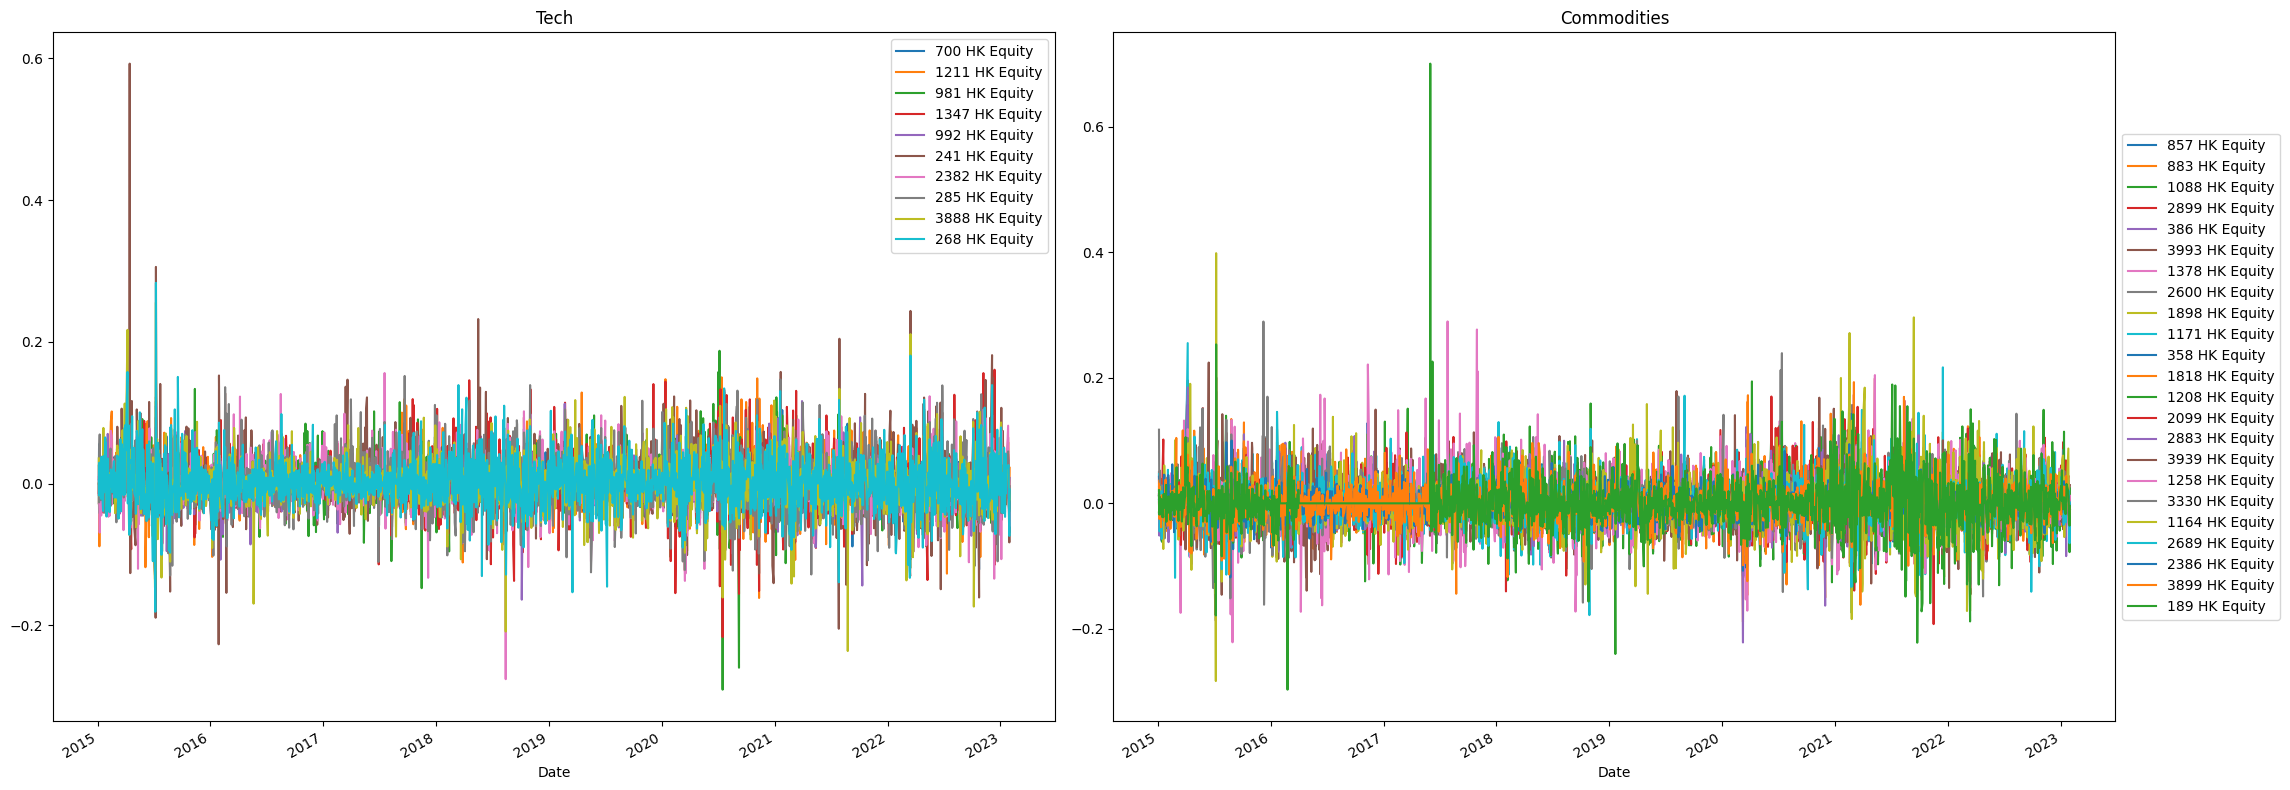

In [9]:
# Checking for outliers visually

fig, axes = plt.subplots(1, 2, figsize=(23, 8))

tech_returns.plot(ax=axes[0])
axes[0].set_title("Tech")

comm_returns.plot(ax=axes[1])
axes[1].set_title("Commodities")
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

In [10]:
# Checking individual plots
output_folder = "/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/plots"
os.makedirs(output_folder, exist_ok=True)

for asset in comm_returns.columns:
    
    plt.figure(figsize=(10, 4))
    
    comm_returns[asset].plot()
    plt.title(asset)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    
    filename = asset.replace(" ", "_") + ".png"
    filepath = os.path.join(output_folder, filename)
    
    plt.savefig(filepath)
    plt.close()

for asset in tech_returns.columns:
    
    plt.figure(figsize=(10, 4))
    
    tech_returns[asset].plot()
    plt.title(asset)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    
    filename = asset.replace(" ", "_") + ".png"
    filepath = os.path.join(output_folder, filename)
    
    plt.savefig(filepath)
    plt.close()

"""
Looking at the plots individually, we find that 189 and 1378 HK Equity have
0 change for an extended period of time, hence we remove it.
"""

comm_returns = comm_returns.drop(["189 HK Equity", "1378 HK Equity"], axis=1)
comm_returns.columns

Index(['857 HK Equity', '883 HK Equity', '1088 HK Equity', '2899 HK Equity',
       '386 HK Equity', '3993 HK Equity', '2600 HK Equity', '1898 HK Equity',
       '1171 HK Equity', '358 HK Equity', '1818 HK Equity', '1208 HK Equity',
       '2099 HK Equity', '2883 HK Equity', '3939 HK Equity', '1258 HK Equity',
       '3330 HK Equity', '1164 HK Equity', '2689 HK Equity', '2386 HK Equity',
       '3899 HK Equity'],
      dtype='str')

![image](/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/plots/189_HK_Equity.png)![image](/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/plots/1378_HK_Equity.png)


In [11]:
# Check for outliers with the >5 standard deviations rule
def flag_extreme_zscore(df, threshold=5):
    """
    Calculates the z-score to determine whether returns are ±5 standard deviations away from the mean.
    We will proceed to winsorize the values if so.
    """
    z_scores = (df - df.mean()) / df.std()
    flags = np.abs(z_scores) > threshold
    return flags

tech_flags = flag_extreme_zscore(tech_returns)
tech_outliers = tech_returns[tech_flags].stack().dropna()
print("Tech outlier assets before winsorization:",
      list(tech_outliers.index.get_level_values(1).unique()))

comm_flags = flag_extreme_zscore(comm_returns)
comm_outliers = comm_returns[comm_flags].stack().dropna()
print("Comm outlier assets before winsorization:",
      list(comm_outliers.index.get_level_values(1).unique()))

Tech outlier assets before winsorization: ['3888 HK Equity', '241 HK Equity', '268 HK Equity', '2382 HK Equity', '992 HK Equity', '981 HK Equity', '1347 HK Equity', '1211 HK Equity', '700 HK Equity']
Comm outlier assets before winsorization: ['3993 HK Equity', '1171 HK Equity', '358 HK Equity', '2883 HK Equity', '2099 HK Equity', '3330 HK Equity', '2899 HK Equity', '3939 HK Equity', '1164 HK Equity', '1818 HK Equity', '2386 HK Equity', '883 HK Equity', '2689 HK Equity', '1258 HK Equity', '1088 HK Equity', '2600 HK Equity', '1208 HK Equity', '857 HK Equity', '386 HK Equity', '3899 HK Equity', '1898 HK Equity']


In [12]:
# Winsorize returns to mitigate data errors and extreme spikes
def winsorize(df, lower=0.01, upper=0.99):
    return df.clip(
        lower=df.quantile(lower),
        upper=df.quantile(upper),
        axis=1
    )

tech_returns_win = winsorize(tech_returns)
comm_returns_win = winsorize(comm_returns)

In [13]:
tech_flags_win = flag_extreme_zscore(tech_returns_win)
tech_outliers_win = tech_returns_win[tech_flags_win].stack().dropna()
print("Tech remaining outlier assets:",
      list(tech_outliers_win.index.get_level_values(1).unique()))

comm_flags_win = flag_extreme_zscore(comm_returns_win)
comm_outliers_win = comm_returns_win[comm_flags_win].stack().dropna()
print("Comm remaining outlier assets:",
      list(comm_outliers_win.index.get_level_values(1).unique()))

Tech remaining outlier assets: []
Comm remaining outlier assets: []


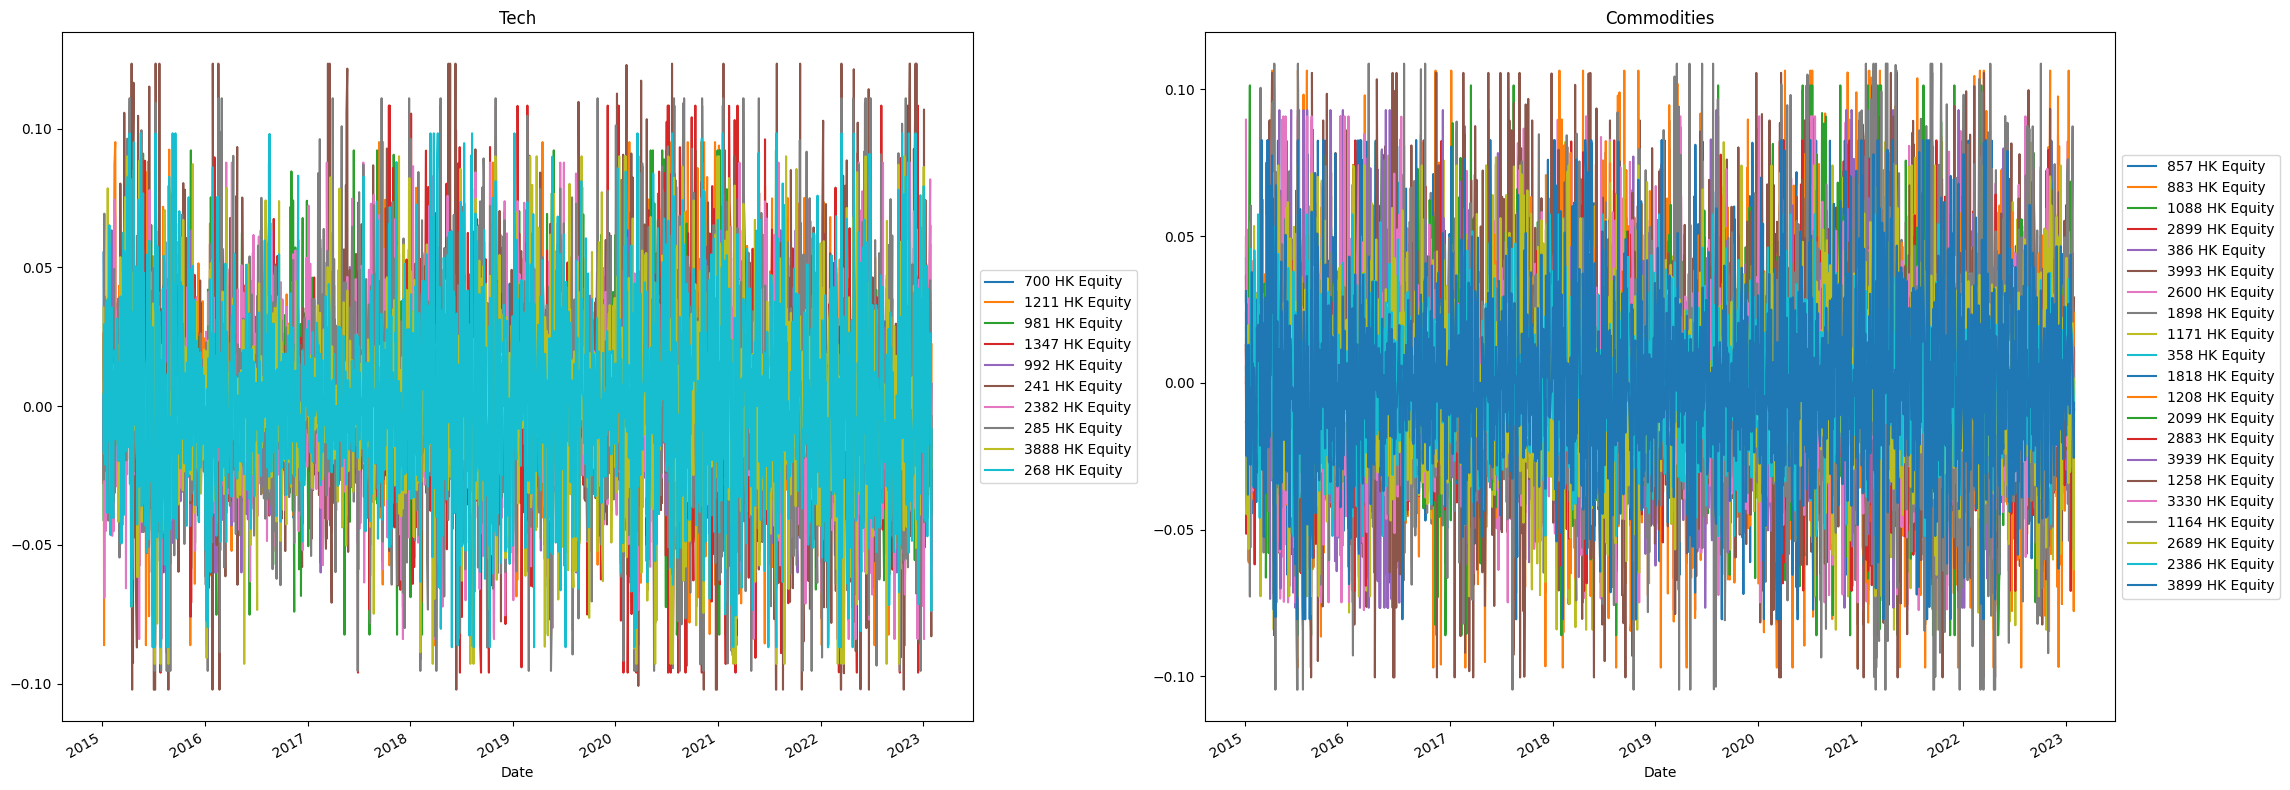

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(23, 8))

tech_returns_win.plot(ax=axes[0], legend=True)
axes[0].set_title("Tech")
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

comm_returns_win.plot(ax=axes[1], legend=True)
axes[1].set_title("Commodities")
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

### Correlation Matrix 

Simple analysis and see whether some equities are highly correlated or not to identify any key patterns between them

In [15]:
# Name remapping
tech_name_map = {
    "700 HK Equity": "700 (Tencent)",
    "9988 HK Equity": "9988 (Alibaba)",
    "1211 HK Equity": "1211 (BYD)",
    "1810 HK Equity": "1810 (Xiaomi)",
    "300 HK Equity": "300 (Midea)",
    "981 HK Equity": "981 (SMIC)",
    "9999 HK Equity": "9999 (NetEase)",
    "3690 HK Equity": "3690 (Meituan)",
    "9618 HK Equity": "9618 (JD.com)",
    "9888 HK Equity": "9888 (Baidu)",
    "9961 HK Equity": "9961 (Trip.com)",
    "6690 HK Equity": "6690 (Haier)",
    "1024 HK Equity": "1024 (Kuaishou)",
    "1347 HK Equity": "1347 (Hua Hong Semi)",
    "2015 HK Equity": "2015 (Li Auto)",
    "6618 HK Equity": "6618 (JD Health)",
    "992 HK Equity": "992 (Lenovo)",
    "9866 HK Equity": "9866 (NIO)",
    "9868 HK Equity": "9868 (XPeng)",
    "1698 HK Equity": "1698 (Tencent Music)",
    "9660 HK Equity": "9660 (Horizon Robotics)",
    "20 HK Equity": "20 (SenseTime)",
    "9626 HK Equity": "9626 (Bilibili)",
    "241 HK Equity": "241 (Alibaba Health)",
    "9863 HK Equity": "9863 (Leapmotor)",
    "2382 HK Equity": "2382 (Sunny Optical)",
    "285 HK Equity": "285 (BYD Electronic)",
    "780 HK Equity": "780 (Tongcheng Travel)",
    "3888 HK Equity": "3888 (Kingsoft)",
    "268 HK Equity": "268 (Kingdee)"
}
comm_name_map = {
    "857 HK Equity": "857 (PetroChina)",
    "883 HK Equity": "883 (CNOOC)",
    "1088 HK Equity": "1088 (China Shenhua)",
    "2899 HK Equity": "2899 (Zijin Mining)",
    "386 HK Equity": "386 (Sinopec)",
    "3993 HK Equity": "3993 (CMOC)",
    "2259 HK Equity": "2259 (Zijin Gold Int.)",
    "2600 HK Equity": "2600 (Aluminum Corp)",
    "1898 HK Equity": "1898 (China Coal)",
    "1772 HK Equity": "1772 (Ganfeng Lithium)",
    "1787 HK Equity": "1787 (Shandong Gold)",
    "1171 HK Equity": "1171 (Yankuang Energy)",
    "358 HK Equity": "358 (Jiangxi Copper)",
    "1818 HK Equity": "1818 (Zhaojin Mining)",
    "1208 HK Equity": "1208 (MMG)",
    "2099 HK Equity": "2099 (China Gold Int.)",
    "2883 HK Equity": "2883 (China Oilfield)",
    "2788 HK Equity": "2788 (Chuangxin Ind.)",
    "3939 HK Equity": "3939 (Wanguo Gold)",
    "3858 HK Equity": "3858 (Jiaxin Res.)",
    "1258 HK Equity": "1258 (China Nonferrous)",
    "3668 HK Equity": "3668 (Yancoal)",
    "3330 HK Equity": "3330 (Lingbao Gold)",
    "1164 HK Equity": "1164 (CGN Mining)",
    "2689 HK Equity": "2689 (Nine Dragons)",
    "2386 HK Equity": "2386 (Sinopec Eng.)",
    "2610 HK Equity": "2610 (Nanshan Aluminium)",
    "3899 HK Equity": "3899 (CIMC Enric)",
}

tech_returns_win = tech_returns_win.rename(columns=lambda x: tech_name_map.get(x, x))
comm_returns_win = comm_returns_win.rename(columns=lambda x: comm_name_map.get(x, x))

In [16]:
# Forming correlation matrices
tech_corr_matrix = tech_returns_win.corr()
comm_corr_matrix = comm_returns_win.corr()

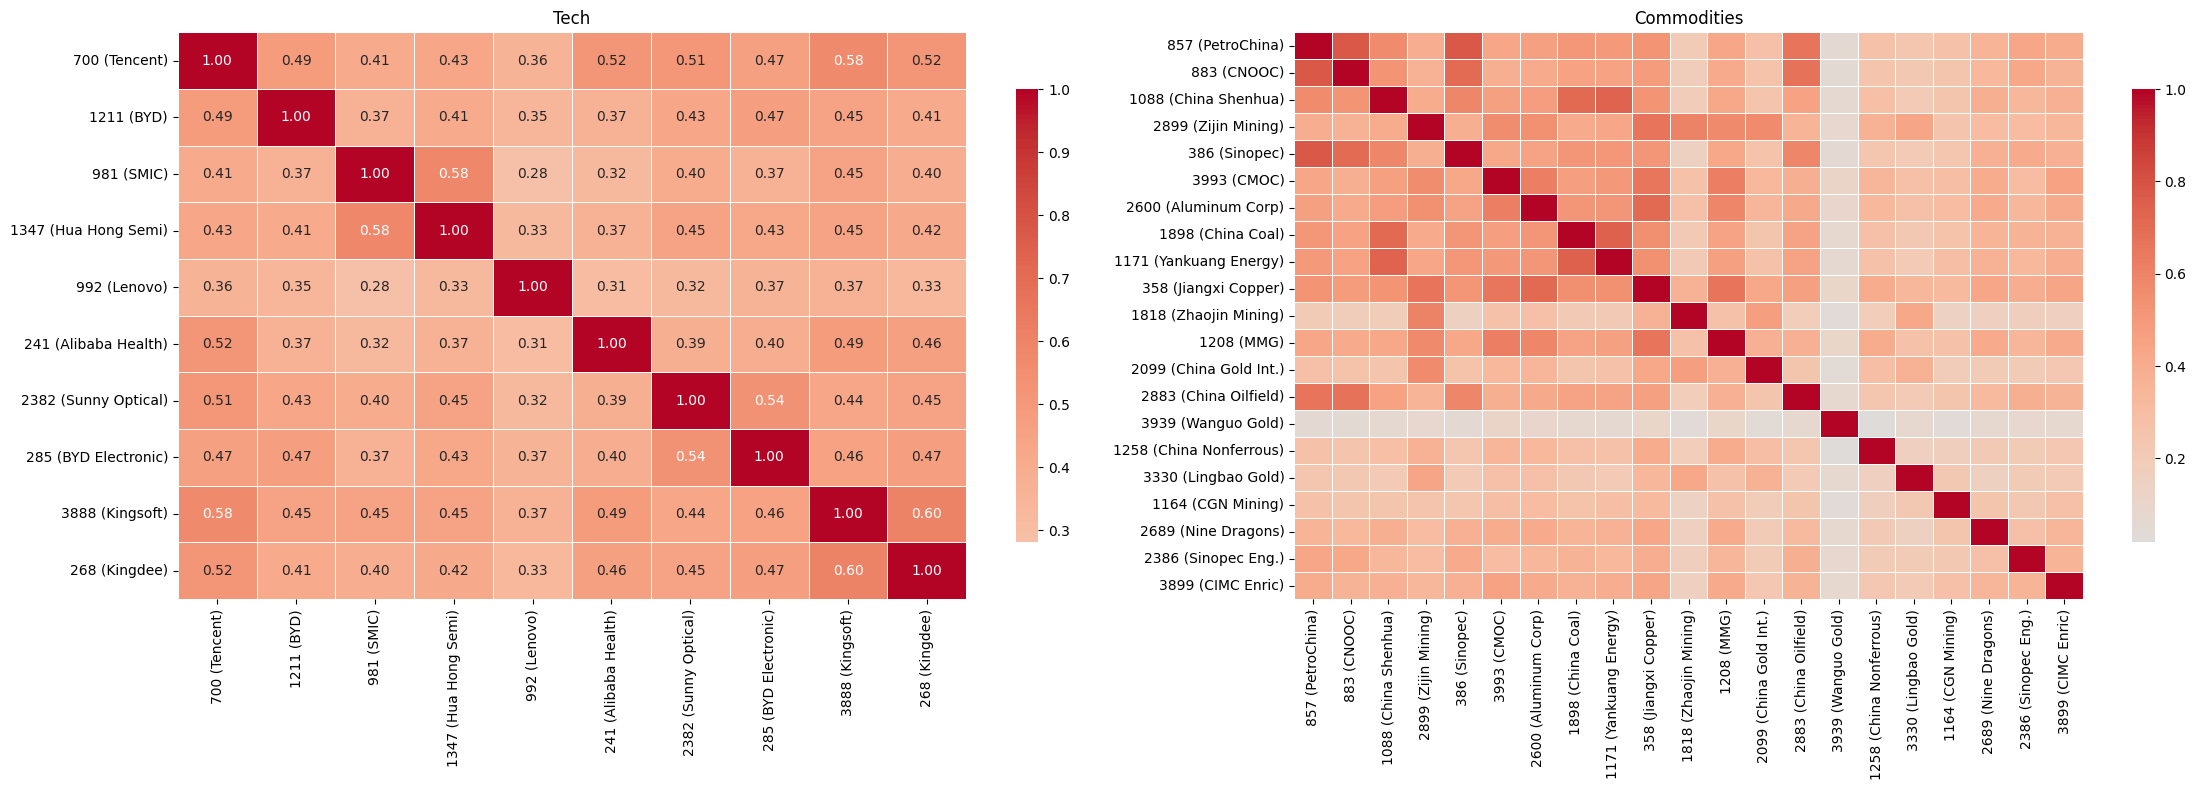

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(23, 8))

# Tech heatmap
sns.heatmap(
    tech_corr_matrix,
    ax=axes[0],
    cmap="coolwarm",
    annot=True,        
    fmt=".2f", 
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Tech")

# Commodities heatmap
sns.heatmap(
    comm_corr_matrix,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Commodities")

plt.tight_layout()
plt.show()

# Run Cointegration test
*Create the algorithm to run stationarity test, differenced regression, Engle-Granger test and estimate the ECM* (cointegration.py)

For each equity pair, I first test whether both series are integrated of order one, I(1), using ADF-based checks. If both satisfy this condition, I estimate the long-run relationship using OLS and then test the residuals for stationarity following the Engle–Granger two-step approach. When residuals are stationary, I conclude that the pair is cointegrated and proceed to estimate an Error Correction Model (ECM).

## Tech Pairs

In [18]:
# Generate pairs 
pairs_t = list(combinations(df1.columns, 2))
pairs_t

[('700 HK Equity', '1211 HK Equity'),
 ('700 HK Equity', '981 HK Equity'),
 ('700 HK Equity', '1347 HK Equity'),
 ('700 HK Equity', '992 HK Equity'),
 ('700 HK Equity', '241 HK Equity'),
 ('700 HK Equity', '2382 HK Equity'),
 ('700 HK Equity', '285 HK Equity'),
 ('700 HK Equity', '3888 HK Equity'),
 ('700 HK Equity', '268 HK Equity'),
 ('1211 HK Equity', '981 HK Equity'),
 ('1211 HK Equity', '1347 HK Equity'),
 ('1211 HK Equity', '992 HK Equity'),
 ('1211 HK Equity', '241 HK Equity'),
 ('1211 HK Equity', '2382 HK Equity'),
 ('1211 HK Equity', '285 HK Equity'),
 ('1211 HK Equity', '3888 HK Equity'),
 ('1211 HK Equity', '268 HK Equity'),
 ('981 HK Equity', '1347 HK Equity'),
 ('981 HK Equity', '992 HK Equity'),
 ('981 HK Equity', '241 HK Equity'),
 ('981 HK Equity', '2382 HK Equity'),
 ('981 HK Equity', '285 HK Equity'),
 ('981 HK Equity', '3888 HK Equity'),
 ('981 HK Equity', '268 HK Equity'),
 ('1347 HK Equity', '992 HK Equity'),
 ('1347 HK Equity', '241 HK Equity'),
 ('1347 HK Equity'

In [19]:
# Create dictionary for cointegration test and run it for each pair using the for loop below
results_t = {}

for x, y in pairs_t:
    pair_name = f"{x}-{y}"   
    
    res = analyze_pair(
        y_series=df1[x],
        x_series=df1[y],
        pair_name=pair_name  
    )
    
    results_t[pair_name] = res

In [20]:
summary_t = summarize_results(results_t)
summary_t

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
0,700 HK Equity-1211 HK Equity,1989,1,1,False,0.391051,0.503449,0.738022,NaN,Residual is not stationary or coint() does not...
1,700 HK Equity-981 HK Equity,1989,1,1,False,0.787983,0.088706,0.229037,NaN,Residual is not stationary or coint() does not...
2,700 HK Equity-1347 HK Equity,1989,1,1,True,0.656611,0.012192,0.046262,-0.004459,Cointegration
3,700 HK Equity-992 HK Equity,1989,1,1,False,0.248683,0.214698,0.442828,NaN,Residual is not stationary or coint() does not...
4,700 HK Equity-241 HK Equity,1989,1,1,False,0.457355,0.301529,0.547243,NaN,Residual is not stationary or coint() does not...
5,700 HK Equity-2382 HK Equity,1989,1,1,False,0.514239,0.046338,0.138049,NaN,Residual is not stationary or coint() does not...
6,700 HK Equity-285 HK Equity,1989,1,1,False,0.569932,0.038476,0.119634,NaN,Residual is not stationary or coint() does not...
7,700 HK Equity-3888 HK Equity,1989,1,1,False,0.825719,0.187748,0.397558,NaN,Residual is not stationary or coint() does not...
8,700 HK Equity-268 HK Equity,1989,1,1,False,0.483073,0.292089,0.535207,NaN,Residual is not stationary or coint() does not...
9,1211 HK Equity-981 HK Equity,1989,1,1,False,1.293912,0.419144,0.665755,NaN,Residual is not stationary or coint() does not...


In [21]:
summary_coint_t = summary_t[summary_t["cointegrated"]]
summary_coint_t

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
2,700 HK Equity-1347 HK Equity,1989,1,1,True,0.656611,0.012192,0.046262,-0.004459,Cointegration
22,981 HK Equity-3888 HK Equity,1989,1,1,True,1.020721,0.011294,0.043337,-0.007065,Cointegration
29,1347 HK Equity-268 HK Equity,1989,1,1,True,0.738739,0.000368,0.002157,-0.019515,Cointegration


In [22]:
# Creating strong and weak pairs (to explore more pair options)

strong_pairs_t = summary_t[
    (summary_t["cointegrated"] == True) & 
    (summary_t["coint_test_pvalue"] < 0.05)]

weaker_pairs_t = summary_t[
    (summary_t["coint_test_pvalue"] < 0.10) &
    (summary_t["coint_test_pvalue"] >= 0.05)
]

# strong_pairs_c.sort_values("coint_test_pvalue").head(10)
weaker_pairs_t.sort_values("coint_test_pvalue").head(10)

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision


#### Visualising pairs

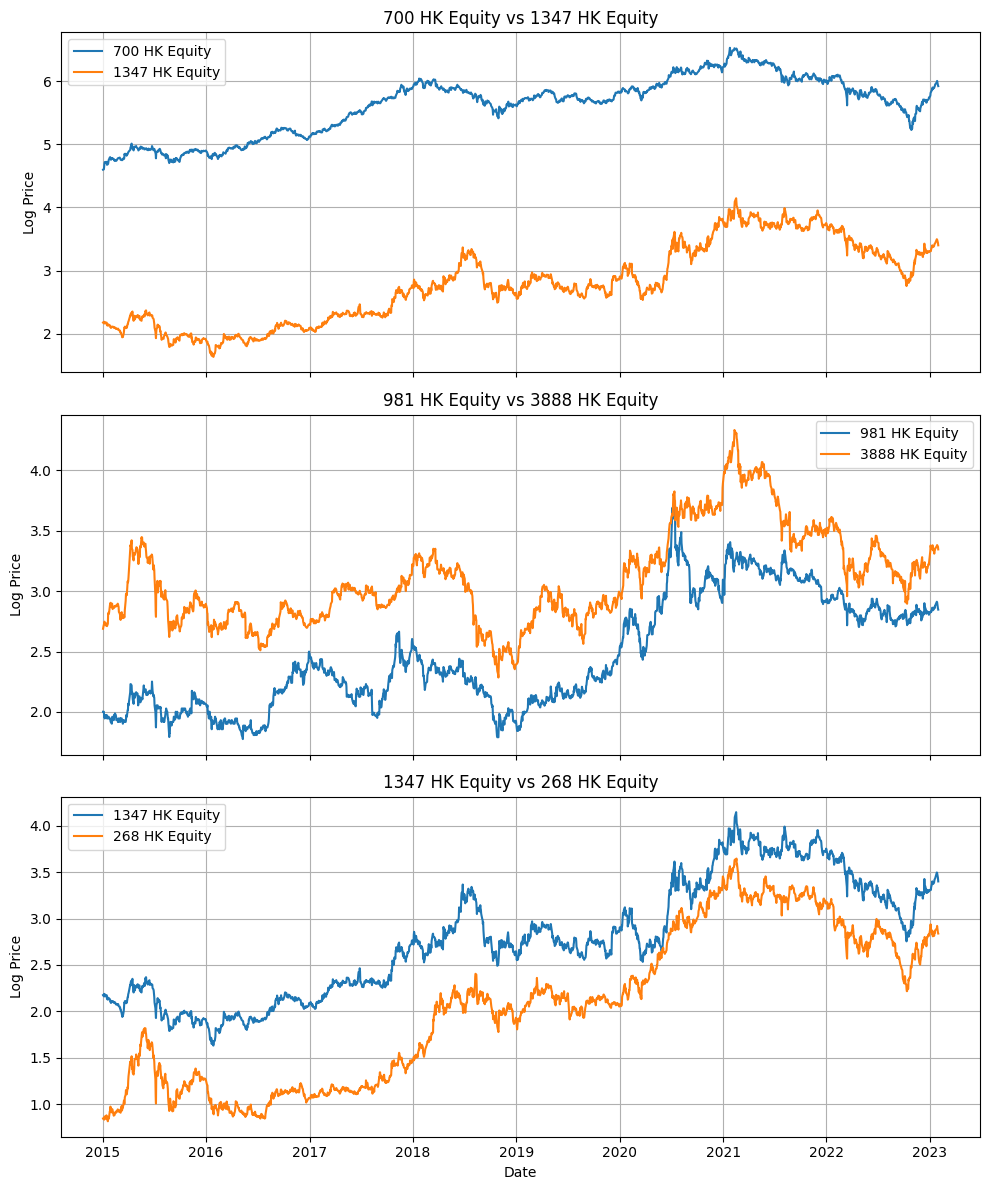

In [ ]:
# Log Price Plot

pairs_t = [
    ("700 HK Equity", "1347 HK Equity"),
    ("981 HK Equity", "3888 HK Equity"),
    ("1347 HK Equity", "268 HK Equity")
]

plot_multiple_price_pairs(df1, pairs_t)

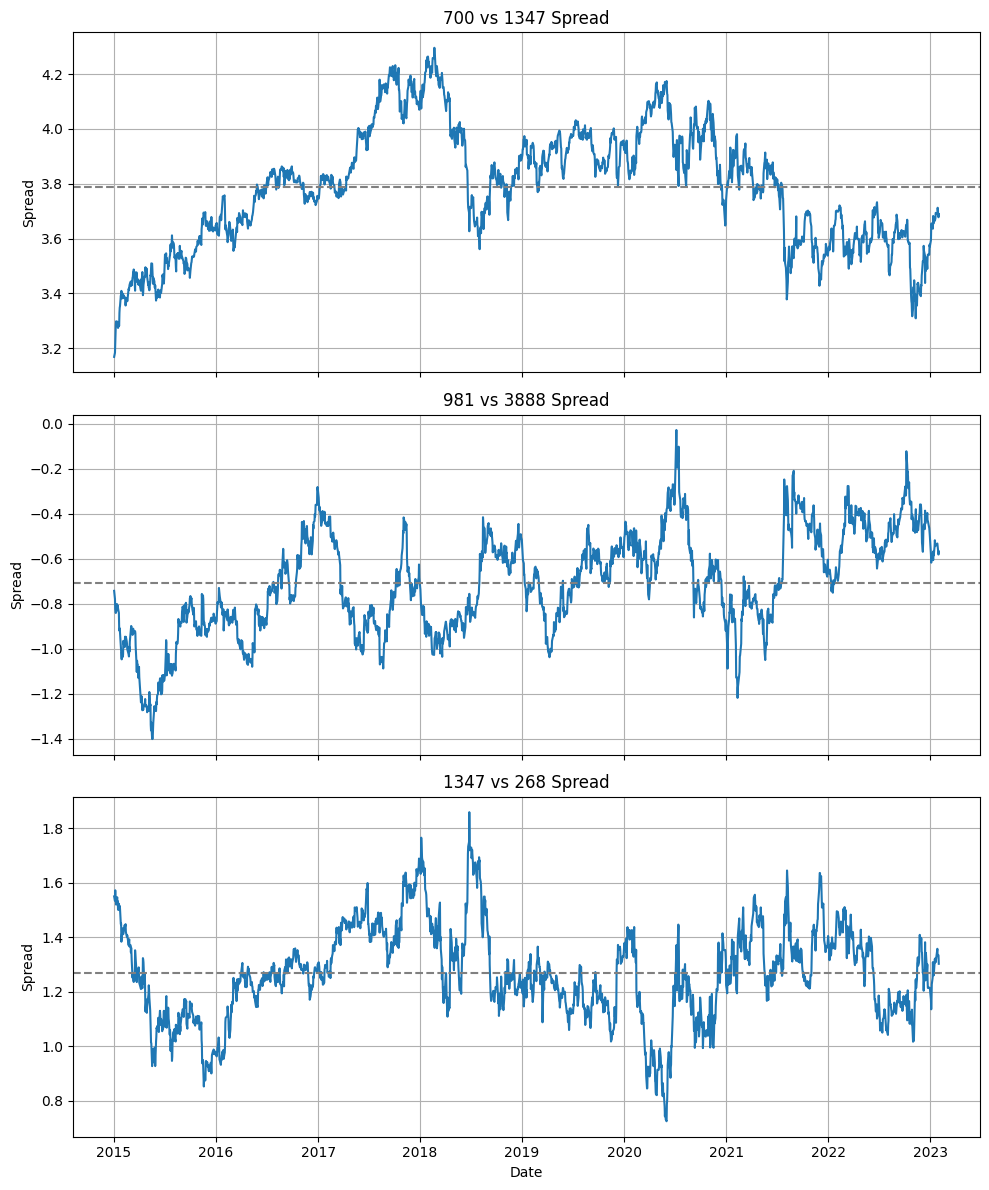

In [26]:
# Calculate spread
spread_t1 = compute_spread(df1["700 HK Equity"], 
                           df1["1347 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[0])

spread_t2 = compute_spread(df1["981 HK Equity"], 
                           df1["3888 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[1])

spread_t3 = compute_spread(df1["1347 HK Equity"], 
                           df1["268 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[2])

spread_dict = {
    "700 vs 1347": spread_t1,
    "981 vs 3888": spread_t2,
    "1347 vs 268": spread_t3
}

plot_multiple_spreads(spread_dict)

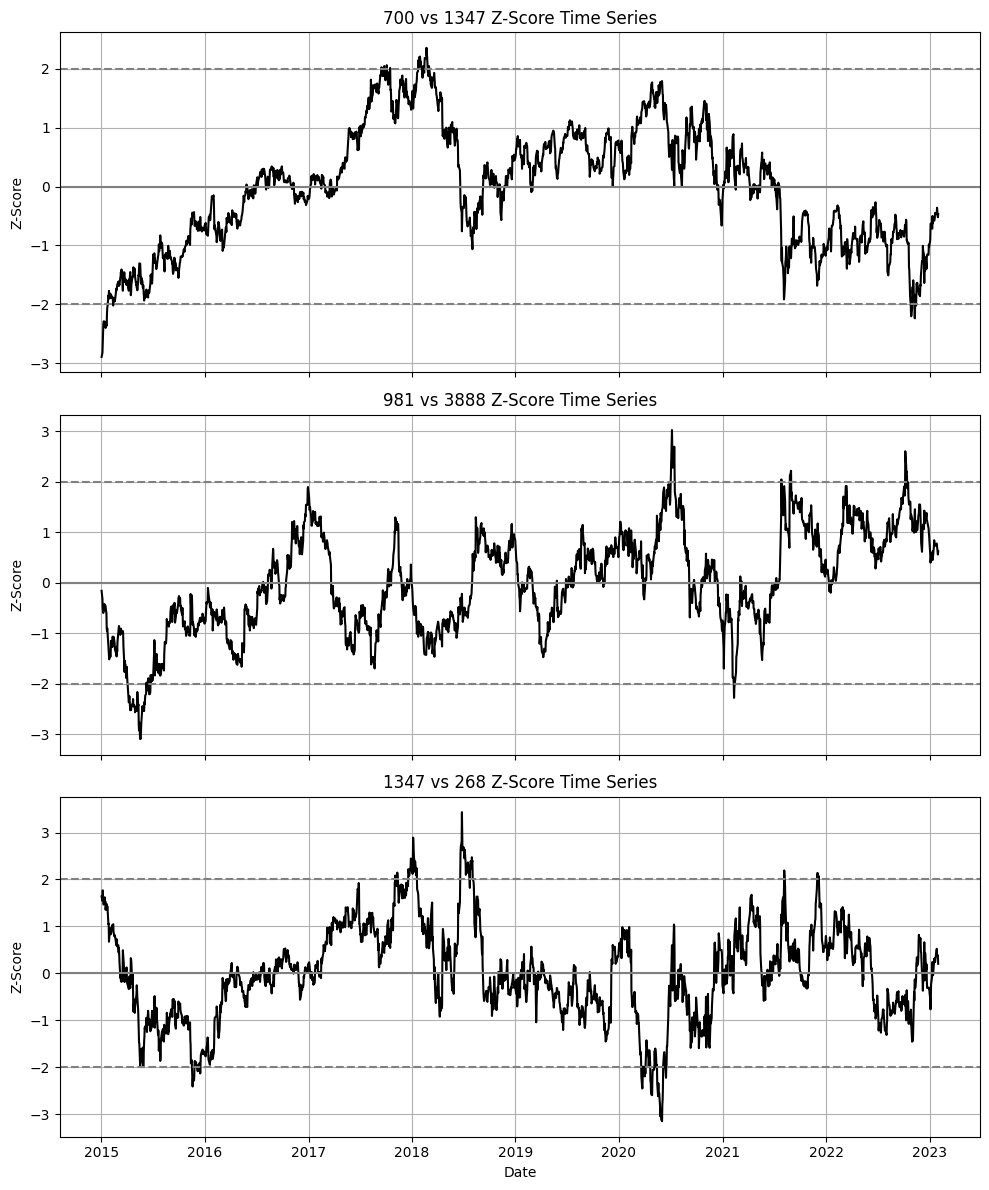

In [27]:
# Calculate z-score
z_t1 = compute_zscore(spread_t1)
z_t2 = compute_zscore(spread_t2)
z_t3 = compute_zscore(spread_t3)

z_dict = {
    "700 vs 1347": z_t1,
    "981 vs 3888": z_t2,
    "1347 vs 268": z_t3
}

plot_multiple_zscores(z_dict)

## Commodities Pairs
*Remember to drop 189 and 1378 as they are have missing data*

In [28]:
# Drop 189 and 1378 HK Equity 
df2 = df2.drop(columns=["189 HK Equity", "1378 HK Equity"])

# Generate pairs 
pairs_c = list(combinations(df2.columns, 2))
pairs_c

[('857 HK Equity', '883 HK Equity'),
 ('857 HK Equity', '1088 HK Equity'),
 ('857 HK Equity', '2899 HK Equity'),
 ('857 HK Equity', '386 HK Equity'),
 ('857 HK Equity', '3993 HK Equity'),
 ('857 HK Equity', '2600 HK Equity'),
 ('857 HK Equity', '1898 HK Equity'),
 ('857 HK Equity', '1171 HK Equity'),
 ('857 HK Equity', '358 HK Equity'),
 ('857 HK Equity', '1818 HK Equity'),
 ('857 HK Equity', '1208 HK Equity'),
 ('857 HK Equity', '2099 HK Equity'),
 ('857 HK Equity', '2883 HK Equity'),
 ('857 HK Equity', '3939 HK Equity'),
 ('857 HK Equity', '1258 HK Equity'),
 ('857 HK Equity', '3330 HK Equity'),
 ('857 HK Equity', '1164 HK Equity'),
 ('857 HK Equity', '2689 HK Equity'),
 ('857 HK Equity', '2386 HK Equity'),
 ('857 HK Equity', '3899 HK Equity'),
 ('883 HK Equity', '1088 HK Equity'),
 ('883 HK Equity', '2899 HK Equity'),
 ('883 HK Equity', '386 HK Equity'),
 ('883 HK Equity', '3993 HK Equity'),
 ('883 HK Equity', '2600 HK Equity'),
 ('883 HK Equity', '1898 HK Equity'),
 ('883 HK Equity

In [29]:
# Create dictionary for cointegration test and run it for each pair using the for loop below
results_c = {}

for x, y in pairs_c:
    pair_name = f"{x}-{y}"   
    
    res = analyze_pair(
        y_series=df2[x],
        x_series=df2[y],
        pair_name=pair_name  
    )
    
    results_c[pair_name] = res

In [30]:
summary_c = summarize_results(results_c)
summary_c

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
0,857 HK Equity-883 HK Equity,1989,1,1,False,0.089878,0.210057,0.429815,NaN,Residual is not stationary or coint() does not...
1,857 HK Equity-1088 HK Equity,1989,1,1,False,-0.086720,0.195585,0.408962,NaN,Residual is not stationary or coint() does not...
2,857 HK Equity-2899 HK Equity,1989,1,1,False,-0.188160,0.264354,0.501320,NaN,Residual is not stationary or coint() does not...
3,857 HK Equity-386 HK Equity,1989,1,1,False,0.930349,0.154707,0.346214,NaN,Residual is not stationary or coint() does not...
4,857 HK Equity-3993 HK Equity,1989,1,1,False,-0.189630,0.216023,0.437849,NaN,Residual is not stationary or coint() does not...
...,...,...,...,...,...,...,...,...,...,...
205,1164 HK Equity-2386 HK Equity,1989,1,1,False,0.131481,0.505018,0.738222,NaN,Residual is not stationary or coint() does not...
206,1164 HK Equity-3899 HK Equity,1989,1,1,False,0.653316,0.204783,0.421975,NaN,Residual is not stationary or coint() does not...
207,2689 HK Equity-2386 HK Equity,1989,1,1,False,-0.069864,0.299267,0.543177,NaN,Residual is not stationary or coint() does not...
208,2689 HK Equity-3899 HK Equity,1989,1,1,False,0.316021,0.312947,0.558755,NaN,Residual is not stationary or coint() does not...


In [31]:
summary_coint_c = summary_c[summary_c["cointegrated"]]
summary_coint_c

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
102,3993 HK Equity-2689 HK Equity,1989,1,1,True,1.268276,0.002154,0.010387,-0.012676,Cointegration
199,1258 HK Equity-3899 HK Equity,1989,1,1,True,1.002393,0.007715,0.031365,-0.008098,Cointegration


In [37]:
# Creating strong and weak pairs (to explore more pair options)

strong_pairs_c = summary_c[
    (summary_c["cointegrated"] == True) & 
    (summary_c["coint_test_pvalue"] < 0.05)]

weaker_pairs_c = summary_c[
    (summary_c["coint_test_pvalue"] < 0.10) &
    (summary_c["coint_test_pvalue"] >= 0.05)
]

# strong_pairs_c.sort_values("coint_test_pvalue").head(10)
weaker_pairs_c.sort_values("coint_test_pvalue").head(10)

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision
18,857 HK Equity-2386 HK Equity,1989,1,1,False,0.819207,0.015105,0.055380,NaN,Residual is not stationary or coint() does not...
44,1088 HK Equity-1171 HK Equity,1989,1,1,False,0.474107,0.018040,0.064194,NaN,Residual is not stationary or coint() does not...
178,2099 HK Equity-1164 HK Equity,1989,1,1,False,0.868272,0.024648,0.082928,NaN,Residual is not stationary or coint() does not...


In [33]:
# Run ECM Filter for further rigour
strong_pairs_c = strong_pairs_c[strong_pairs_c["ecm_coef"] < 0]
weaker_pairs_c = weaker_pairs_c[weaker_pairs_c["ecm_coef"] < 0]

# strong_pairs_c.head(10)
weaker_pairs_c.head(10)

,pair,n_obs,y_order,x_order,cointegrated,hedge_ratio,residual_adf_pvalue,coint_test_pvalue,ecm_coef,decision


### Visualising pairs

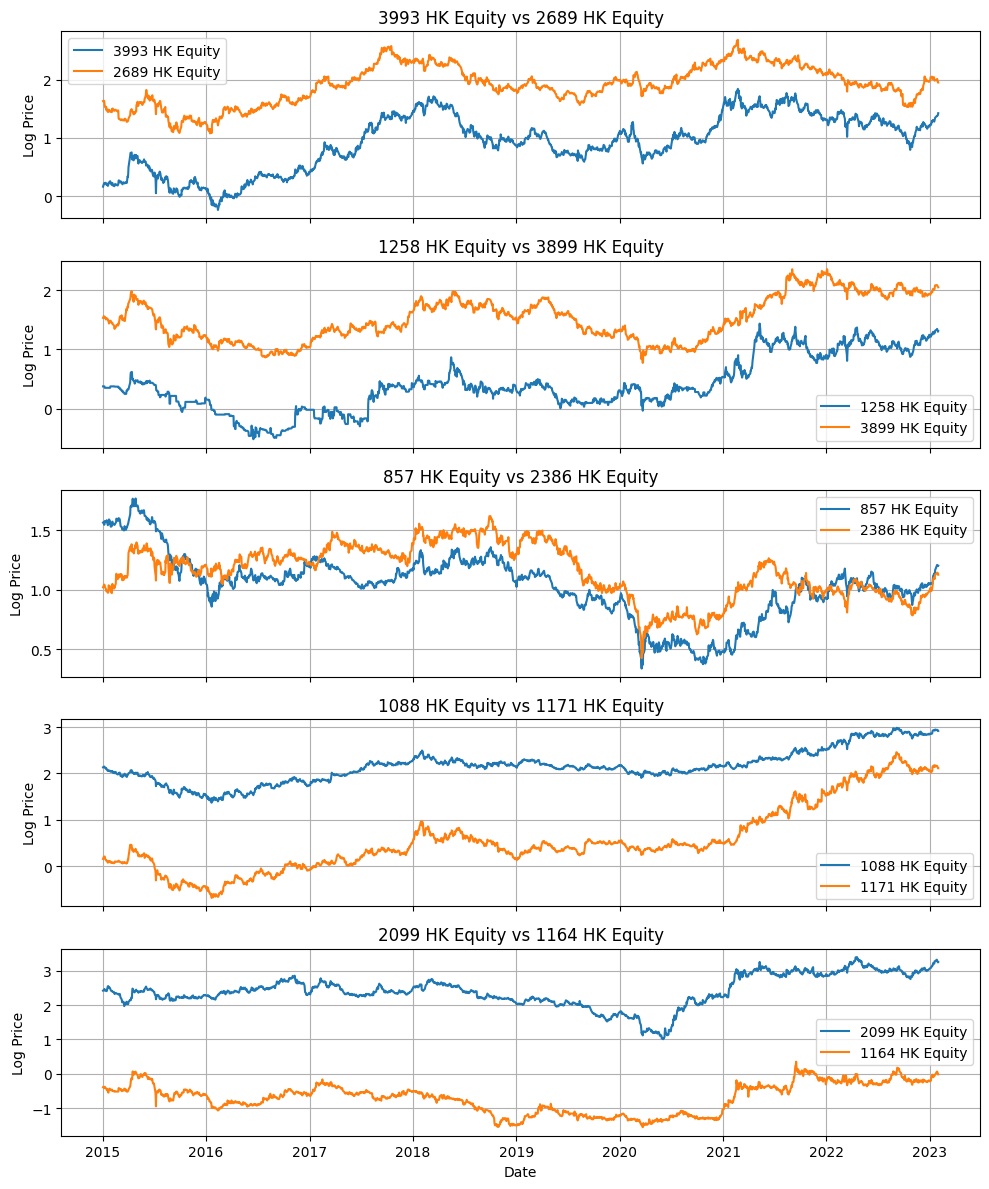

In [41]:
# Log Price Plot

pairs_c = [
    ("3993 HK Equity", "2689 HK Equity"),
    ("1258 HK Equity", "3899 HK Equity"),
    ("857 HK Equity", "2386 HK Equity"),
    ("1088 HK Equity", "1171 HK Equity"),
    ("2099 HK Equity", "1164 HK Equity")
]

plot_multiple_price_pairs(df2, pairs_c)

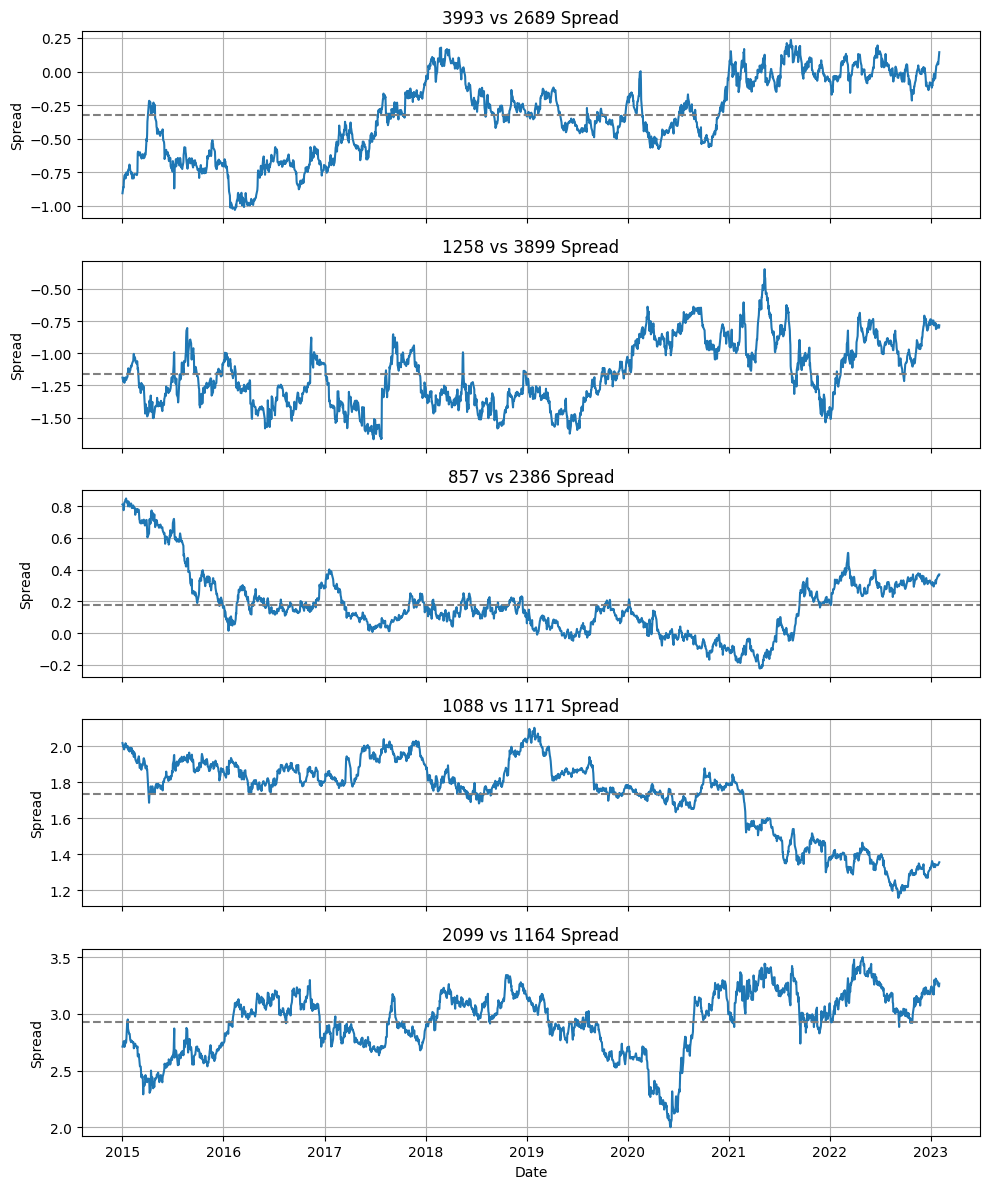

In [43]:
# Calculate spread
spread_c1 = compute_spread(df2["3993 HK Equity"], 
                           df2["2689 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[0])

spread_c2 = compute_spread(df2["1258 HK Equity"], 
                           df2["3899 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[1])

spread_c3 = compute_spread(df2["857 HK Equity"], 
                           df2["2386 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[2])

spread_c4 = compute_spread(df2["1088 HK Equity"], 
                           df2["1171 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[2])

spread_c5 = compute_spread(df2["2099 HK Equity"], 
                           df2["1164 HK Equity"], 
                           summary_coint_t["hedge_ratio"].iloc[2])

spread_dict_c = {
    "3993 vs 2689": spread_c1,
    "1258 vs 3899": spread_c2,
    "857 vs 2386": spread_c3,
    "1088 vs 1171": spread_c4,
    "2099 vs 1164": spread_c5
}

plot_multiple_spreads(spread_dict_c)

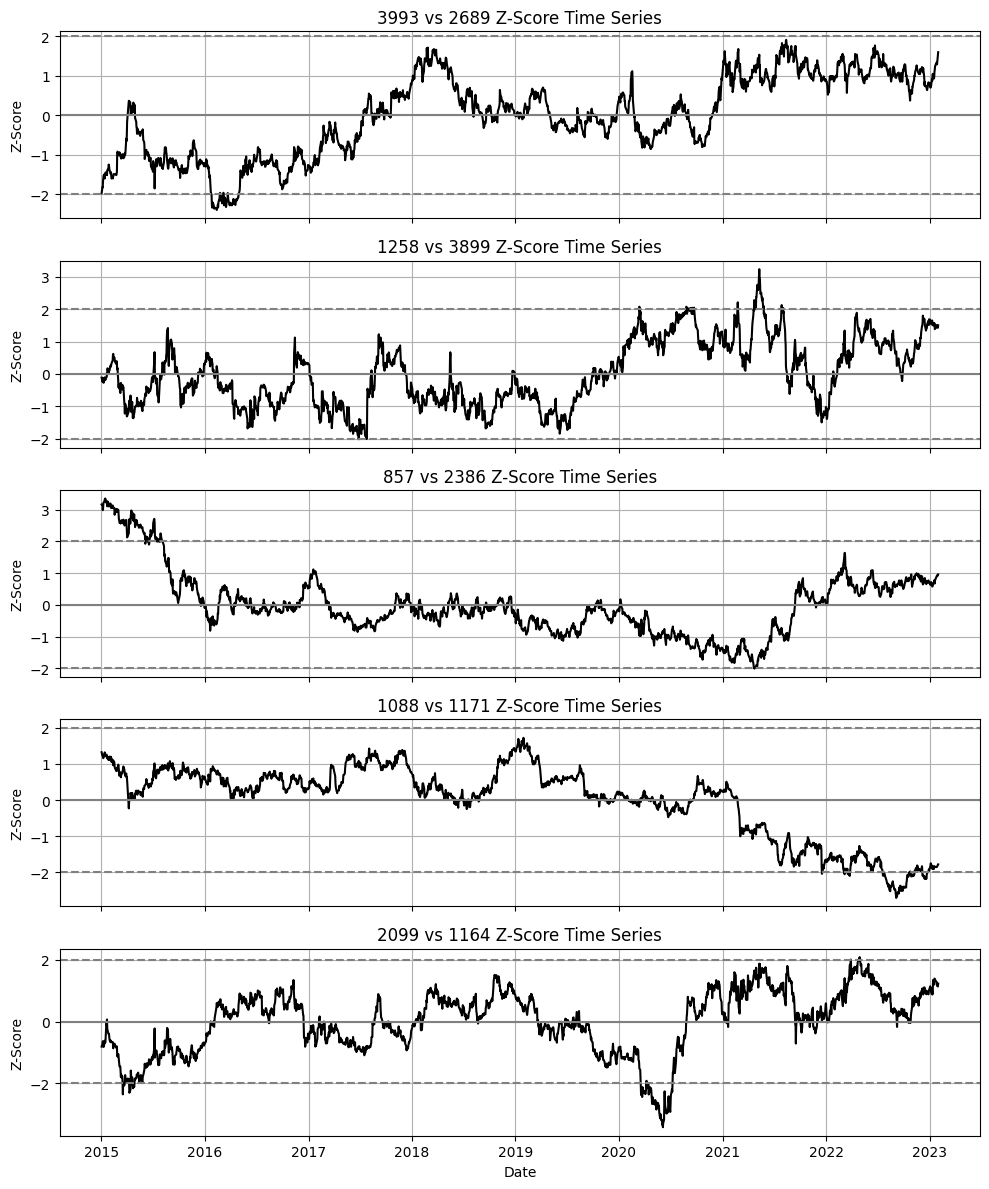

In [44]:
# Calculate z-score
z_c1 = compute_zscore(spread_c1)
z_c2 = compute_zscore(spread_c2)
z_c3 = compute_zscore(spread_c3)
z_c4 = compute_zscore(spread_c4)
z_c5 = compute_zscore(spread_c5)

z_dict_c = {
    "3993 vs 2689": z_c1,
    "1258 vs 3899": z_c2,
    "857 vs 2386": z_c3,
    "1088 vs 1171": z_c4,
    "2099 vs 1164": z_c5

}

plot_multiple_zscores(z_dict_c)

# Create pairs strategy (baseline + Kalman)
- Start with the static hedge ratio (using OLS) (pairs-det.py)
- Develop the Kalman Filter script here (kalman.py)
- Create the dynamic model here and standardise to form the trading signal (pairs-det.py)

$$
\text{Current State Estimated Value} = \text{Predicted Value of Current State} + \text{Kalman Gain} \times (\text{Measured Value - Predicted Value of State})
$$

# Implementation 
- For backtest here and compare the Kalman indicator to the baseline and a simple long strategy of only Asset A and Asset B (backtest.py)